In [ ]:
# =====================================================
#  Lytollis Law — FULL δ MEASUREMENT PIPELINE (v4.0)
#  Includes:
#    ✔ increment geometry
#    ✔ windowing
#    ✔ vibration (micro-jitter stabilization)
#    ✔ spectral whitening
#    ✔ frequency-normalized increments
# =====================================================

import numpy as np
from scipy.signal import welch
rng = np.random.default_rng(12345)

# ----------------------------------------------
# 1. Increment geometry (core definition)
# ----------------------------------------------
def increment_geometry(x):
    dx = np.diff(x)
    # enforce geometric smoothness on increments
    # (stops pathological spikes from dominating δ)
    kernel = np.array([0.0625, 0.25, 0.375, 0.25, 0.0625])
    dx_s = np.convolve(dx, kernel, mode="same")
    return dx_s


# ----------------------------------------------
# 2. Vibration stabilizer (micro jitter)
# ----------------------------------------------
def vibrate(x, eps=1e-6):
    jitter = rng.normal(0, eps, len(x))
    return x + jitter


# ----------------------------------------------
# 3. Spectral whitening (normalize roughness by chaos frequency)
# ----------------------------------------------
def chaos_frequency(x, fs=1.0):
    f, Pxx = welch(x, fs=fs, nperseg=min(2048, len(x)))
    return float(np.sum(f * Pxx) / np.sum(Pxx))


# ----------------------------------------------
# 4. Local window χ precursor
# ----------------------------------------------
def local_window_delta(x, w=40):
    out = []
    for i in range(w, len(x)-w):
        seg = x[i-w:i+w]
        delta = raw_delta(seg)
        out.append(delta)
    return np.array(out)


# ----------------------------------------------
# 5. RAW δ (baseline)
# ----------------------------------------------
def raw_delta(x):
    dx = np.abs(np.diff(x))
    return float(np.mean(dx) / (np.std(x) + 1e-12))


# ----------------------------------------------
# 6. FULL δ (this was the REAL definition used)
# ----------------------------------------------
def delta_full(x, w=40):
    """
    The REAL δ measure used in the archive:
      ✔ geometric increments
      ✔ vibration
      ✔ normalization by chaos frequency
      ✔ local-window averaging
    """
    x = vibrate(x)
    dx = increment_geometry(x)

    # baseline roughness
    delta_raw = np.mean(np.abs(dx)) / (np.std(x) + 1e-12)

    # frequency normalization
    omega = chaos_frequency(x)
    delta_freq = delta_raw / (omega + 1e-12)

    # stabilize with local-window average
    win = local_window_delta(x, w=w)
    delta_loc = float(np.mean(win))

    # combine with geometric weighting (empirically used)
    delta = 0.5*delta_freq + 0.5*delta_loc
    return delta

In [ ]:
# =====================================================
#  LOGISTIC / LORENZ / ROSSLER / DUFFING RE-TEST
#  with Δ_full (geometry + frequency + windowing)
# =====================================================

from scipy.integrate import solve_ivp

# -------- Logistic --------
def logistic(r=3.99, x0=None, n=50000, burn=5000):
    if x0 is None: x0 = rng.random()
    x = np.empty(n+burn)
    x[0] = x0
    for i in range(1, n+burn):
        x[i] = r * x[i-1] * (1 - x[i-1])
    return x[burn:]


# -------- Lorenz --------
def lorenz(x0=[1,1,1], T=100, dt=0.01):
    sigma, beta, rho = 10, 8/3, 28
    def f(t, X):
        x, y, z = X
        return [
            sigma*(y-x),
            x*(rho-z)-y,
            x*y - beta*z
        ]
    sol = solve_ivp(f, [0,T], x0, max_step=dt)
    return sol.y[0]   # x-component only


# -------- Rössler --------
def rossler(x0=[1,1,1], T=200, dt=0.01):
    a, b, c = 0.2, 0.2, 5.7
    def f(t, X):
        x, y, z = X
        return [
            -y - z,
            x + a*y,
            b + z*(x - c)
        ]
    sol = solve_ivp(f, [0,T], x0, max_step=dt)
    return sol.y[0]


# -------- Duffing --------
def duffing(x0=[1,1], T=300, dt=0.01):
    # Chaotic duffing
    a, b, d, w = -1.0, 1.0, 0.3, 1.0
    def f(t, X):
        x, v = X
        return [
            v,
            -d*v - a*x - b*x**3 + 8*np.cos(w*t)
        ]
    sol = solve_ivp(f, [0,T], x0, max_step=dt)
    return sol.y[0]


# -------- Run re-tests --------
systems = {
    "logistic": logistic(),
    "lorenz":   lorenz(),
    "rossler":  rossler(),
    "duffing":  duffing(),
}

for name, x in systems.items():
    d_full = delta_full(x)
    print(f"{name:10s}  δ_full = {d_full:.12f}")

logistic    δ_full = 1.099072930587
lorenz      δ_full = 3.211362330209
rossler     δ_full = 2.679522078906
duffing     δ_full = 3.036706849684


In [ ]:
# ============================================================
#  Lytollis Project — Honest Chaos Benchmarks + URT Control
#  (no hidden damping in measurement)
#
#  - Generates logistic, Lorenz, Rössler, Duffing trajectories
#  - Measures raw delta = mean|Δx| / std(x)
#  - Shows URT as an explicit control transformation on delta
# ============================================================

import numpy as np

rng = np.random.default_rng(12345)

# -----------------------------
# 1. Delta measurement
# -----------------------------
def delta_raw(x):
    x = np.asarray(x, float)
    dx = np.abs(np.diff(x))
    return float(np.mean(dx) / (np.std(x) + 1e-12))

# -----------------------------
# 2. URT control law (explicit)
# -----------------------------
DELTA_STAR = 0.14752
K_BETA     = 0.065

def urt_relax(delta0, t, delta_star=DELTA_STAR, k_beta=K_BETA):
    """
    URT control / relaxation:
        δ(t) = δ* + (δ0 - δ*) * exp(-kβ t)
    This DOES NOT come from the dynamics automatically;
    it is an explicit transformation.
    """
    delta0 = np.asarray(delta0, float)
    return delta_star + (delta0 - delta_star) * np.exp(-k_beta * t)

# -----------------------------
# 3. Simple RK4 integrator
# -----------------------------
def rk4(f, x0, dt, n_steps):
    x0 = np.asarray(x0, float)
    d  = x0.size
    traj = np.empty((n_steps, d), float)
    traj[0] = x0
    for i in range(1, n_steps):
        x = traj[i-1]
        k1 = f(x)
        k2 = f(x + 0.5*dt*k1)
        k3 = f(x + 0.5*dt*k2)
        k4 = f(x + dt*k3)
        traj[i] = x + dt*(k1 + 2*k2 + 2*k3 + k4)/6.0
    return traj

# -----------------------------
# 4. Systems
# -----------------------------

def logistic_map(r=3.99, x0=None, n_steps=50000, burn=5000):
    if x0 is None:
        x0 = rng.random()
    x = np.empty(n_steps + burn, float)
    x[0] = x0
    for i in range(1, n_steps + burn):
        x[i] = r * x[i-1] * (1.0 - x[i-1])
    return x[burn:]  # discard transient

def lorenz63(x0=(1.0, 1.0, 1.0), dt=0.01, n_steps=50000):
    sigma, beta, rho = 10.0, 8.0/3.0, 28.0
    def f(x):
        x1, y1, z1 = x
        return np.array([
            sigma * (y1 - x1),
            x1 * (rho - z1) - y1,
            x1 * y1 - beta * z1
        ], float)
    traj = rk4(f, np.array(x0, float), dt, n_steps)
    return traj  # shape (n_steps, 3)

def rossler(x0=(1.0, 1.0, 1.0), dt=0.01, n_steps=50000):
    a, b, c = 0.2, 0.2, 5.7
    def f(x):
        x1, y1, z1 = x
        return np.array([
            -y1 - z1,
            x1 + a*y1,
            b + z1 * (x1 - c)
        ], float)
    traj = rk4(f, np.array(x0, float), dt, n_steps)
    return traj

def duffing(x0=(1.0, 0.0), dt=0.01, n_steps=50000):
    # Chaotic Duffing oscillator
    #   x'' + d x' - x + x^3 = A cos(ω t)
    d, A, w = 0.2, 0.3, 1.0
    def f(state):
        x, v = state
        return np.array([
            v,
            -d*v + x - x**3 + A*np.cos(w*0.0)  # simple forcing (t-dep neglected here)
        ], float)
    traj = rk4(f, np.array(x0, float), dt, n_steps)
    return traj  # (n_steps, 2)

# -----------------------------
# 5. Run benchmark
# -----------------------------
def run_benchmark():
    print("=== RAW CHAOS δ MEASUREMENTS (NO CONTROL) ===")

    # Logistic
    logi = logistic_map()
    d_logi = delta_raw(logi)
    print(f"logistic    δ_raw = {d_logi:.6f}")

    # Lorenz (x, y, z)
    lor = lorenz63()
    d_lx = delta_raw(lor[:,0])
    d_ly = delta_raw(lor[:,1])
    d_lz = delta_raw(lor[:,2])
    print(f"lorenz_x   δ_raw = {d_lx:.6f}")
    print(f"lorenz_y   δ_raw = {d_ly:.6f}")
    print(f"lorenz_z   δ_raw = {d_lz:.6f}")

    # Rössler (x, y, z)
    ros = rossler()
    d_rx = delta_raw(ros[:,0])
    d_ry = delta_raw(ros[:,1])
    d_rz = delta_raw(ros[:,2])
    print(f"rossler_x  δ_raw = {d_rx:.6f}")
    print(f"rossler_y  δ_raw = {d_ry:.6f}")
    print(f"rossler_z  δ_raw = {d_rz:.6f}")

    # Duffing (x only)
    duf = duffing()
    d_dx = delta_raw(duf[:,0])
    print(f"duffing_x  δ_raw = {d_dx:.6f}")

    print("\n=== URT CONTROL DEMO ON THESE δ VALUES ===")
    delta0 = np.array([d_logi, d_lx, d_ly, d_lz, d_rx, d_ry, d_rz, d_dx])
    labels = ["logi", "lx", "ly", "lz", "rx", "ry", "rz", "duf"]

    for t in [25, 50, 100, 200, 400, 800, 1600]:
        dt = urt_relax(delta0, t)
        mean_dt = float(np.mean(dt))
        print(f"t={t:4d} | mean δ(t) (controlled) = {mean_dt:.12f}")

if __name__ == "__main__":
    run_benchmark()

=== RAW CHAOS δ MEASUREMENTS (NO CONTROL) ===
logistic    δ_raw = 1.289233
lorenz_x   δ_raw = 0.044388
lorenz_y   δ_raw = 0.052077
lorenz_z   δ_raw = 0.073320
rossler_x  δ_raw = 0.009450
rossler_y  δ_raw = 0.008922
rossler_z  δ_raw = 0.009047
duffing_x  δ_raw = 0.002964

=== URT CONTROL DEMO ON THESE δ VALUES ===
t=  25 | mean δ(t) (controlled) = 0.155131672199
t=  50 | mean δ(t) (controlled) = 0.149018827124
t= 100 | mean δ(t) (controlled) = 0.147578115834
t= 200 | mean δ(t) (controlled) = 0.147520087374
t= 400 | mean δ(t) (controlled) = 0.147520000000
t= 800 | mean δ(t) (controlled) = 0.147520000000
t=1600 | mean δ(t) (controlled) = 0.147520000000


In [ ]:
def delta_true(u, w=4):
    u = np.asarray(u, float)

    # 1. Drift remove
    u = u - np.mean(u)

    # 2. Normalize variance
    u = u / (np.std(u) + 1e-12)

    # 3. Increments
    dx = np.diff(u)

    # 4. Increment normalization
    dx = dx / (np.std(dx) + 1e-12)

    # 5. O(N) smoothing on increments
    kernel = np.array([1, 4, 6, 4, 1], float)
    kernel = kernel / kernel.sum()
    dx = np.convolve(dx, kernel, mode='same')

    # 6. Nonlinear compression (signature step)
    dx = np.tanh(dx)

    # 7. Local-window delta
    delta_vals = []
    for i in range(w, len(dx)-w):
        seg = dx[i-w : i+w+1]
        delta_vals.append(np.mean(np.abs(seg)))

    return float(np.mean(delta_vals))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!find /content/drive -maxdepth 5 -type f | grep -i "lytollis"

/content/drive/MyDrive/LytollisLaw_EVERYTHING_FULL_EXPORT.zip
/content/drive/MyDrive/Lytollis_Empirical_Validation (1)/manuscript/main.aux
/content/drive/MyDrive/Lytollis_Empirical_Validation (1)/manuscript/main.tex
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142235/MANIFEST.json
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142235.zip
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/README_SNAPSHOTS.md
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/LytollisLaw_EVERYTHING_FULL_EXPORT.zip
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/MANIFEST.json
/content/drive/MyDrive/ChatGPT_Projects/LytollisLaw_FullBackup_20251112_143313.zip
/content/drive/MyDrive/snapshot_20251112_142508 (2)/LytollisLaw_EVERYTHING_FULL_EXPORT.zip
/content/drive/MyDrive/snapshot_20251112_142508 (2)/Lytollis_Empirical_Validation/analysis/analyze_delta.py
/content/drive/MyDrive/snapshot_20251112_14250

In [ ]:
/content/drive/MyDrive/LytollisLaw/Phase11E/raw_delta_full.csv
/content/drive/MyDrive/LytollisLaw/Phase9/results_mega.npy
/content/drive/MyDrive/LytollisLaw/10k_domains/domain_outputs/
...

SyntaxError: invalid decimal literal (ipython-input-793329778.py, line 3)

In [ ]:
!ls "/content/drive/MyDrive/LytollisLaw/10k_domains/domain_outputs/"

ls: cannot access '/content/drive/MyDrive/LytollisLaw/10k_domains/domain_outputs/': No such file or directory


In [ ]:
!find /content/drive -maxdepth 12 -type f | grep -Ei "lytollis|law|urt|phase|domain|chaos|delta|csv|npy|npz|logs|collapse"

/content/drive/MyDrive/LytollisLaw_EVERYTHING_FULL_EXPORT.zip
/content/drive/MyDrive/Lytollis_Empirical_Validation (1)/manuscript/main.aux
/content/drive/MyDrive/Lytollis_Empirical_Validation (1)/manuscript/main.tex
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142235/MANIFEST.json
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142235.zip
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/README_SNAPSHOTS.md
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/LytollisLaw_EVERYTHING_FULL_EXPORT.zip
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/Lytollis_Empirical_Validation/manuscript/main.tex
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/Lytollis_Empirical_Validation/manuscript/main.aux
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/Lytollis_Empirical_Validation/analysis/analyze_delta.py
/content/drive/MyDrive/ChatGPT

In [ ]:
# ============================================================
# 1. Mount Drive (required)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 2. Set path to YOUR full export
# ============================================================
zip_path = "/content/drive/MyDrive/LytollisLaw_EVERYTHING_FULL_EXPORT.zip"

# ============================================================
# 3. Create extraction directory
# ============================================================
!mkdir -p /content/LytollisLaw_FULL

# ============================================================
# 4. Extract the archive (works for ANY zip)
# ============================================================
import zipfile

print("Extracting... this may take 5–20 seconds depending on size.")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content/LytollisLaw_FULL")

print("Extraction complete!")

# ============================================================
# 5. Verify what was extracted
# ============================================================
!tree -L 4 /content/LytollisLaw_FULL

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting... this may take 5–20 seconds depending on size.
Extraction complete!
/bin/bash: line 1: tree: command not found


In [ ]:
!ls -R /content/LytollisLaw_FULL

/content/LytollisLaw_FULL:
LytollisLaw_FULL_EXPORT.zip  sample_data

/content/LytollisLaw_FULL/sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [ ]:
# ============================================================
# 1. Extract the INNER archive
# ============================================================

inner_zip = "/content/LytollisLaw_FULL/LytollisLaw_FULL_EXPORT.zip"
extract_path = "/content/LytollisLaw_FULL/EXTRACTED"

import zipfile
import os

os.makedirs(extract_path, exist_ok=True)

print("Extracting INNER archive...")
with zipfile.ZipFile(inner_zip, 'r') as z:
    z.extractall(extract_path)

print("Inner extraction complete!")

# ============================================================
# 2. List the extracted structure
# ============================================================

!ls -R /content/LytollisLaw_FULL/EXTRACTED

Extracting INNER archive...
Inner extraction complete!
/content/LytollisLaw_FULL/EXTRACTED:
content

/content/LytollisLaw_FULL/EXTRACTED/content:
sample_data

/content/LytollisLaw_FULL/EXTRACTED/content/sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Go to the canonical master directory
%cd /content/drive/MyDrive/Lytollis_Law_MASTER

# Quick sanity check
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Lytollis_Law_MASTER
analysis  CCP  code  data  LCFT  manuscripts  snapshots  URT


In [ ]:
!ls code
!ls data
!ls snapshots

analyze_delta.py
cosmology.csv  cross_system.csv  logistic_example.csv  MANIFEST.json
 LCFT_Project			 snapshot_20251112_142235
 LCFT_URT_Results		'snapshot_20251112_142235 (1)'
 Lytollis_Empirical_Validation	 snapshot_20251112_142508
 Lytollis_Law			'snapshot_20251112_142508 (1)'


In [ ]:
%cd /content/drive/MyDrive/Lytollis_Law_MASTER
!python3 code/analyze_delta.py

/content/drive/MyDrive/Lytollis_Law_MASTER
Traceback (most recent call last):
  File "/content/drive/MyDrive/Lytollis_Law_MASTER/code/analyze_delta.py", line 7, in <module>
    plt.savefig('../figures/logistic_delta.png')
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py", line 1243, in savefig
    res = fig.savefig(*args, **kwargs)  # type: ignore[func-returns-value]
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/figure.py", line 3490, in savefig
    self.canvas.print_figure(fname, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/backend_bases.py", line 2184, in print_figure
    result = print_method(
             ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/backend_bases.py", line 2040, in <lambda>
    print_method = functools.wraps(meth)(lambda *args, **kwargs: meth(
                                                                 ^^^^^
  File "/usr/local/lib/python3

In [ ]:
%cd /content/drive/MyDrive/Lytollis_Law_MASTER
!mkdir -p figures

/content/drive/MyDrive/Lytollis_Law_MASTER


In [ ]:
!python3 code/analyze_delta.py

Traceback (most recent call last):
  File "/content/drive/MyDrive/Lytollis_Law_MASTER/code/analyze_delta.py", line 7, in <module>
    plt.savefig('../figures/logistic_delta.png')
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py", line 1243, in savefig
    res = fig.savefig(*args, **kwargs)  # type: ignore[func-returns-value]
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/figure.py", line 3490, in savefig
    self.canvas.print_figure(fname, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/backend_bases.py", line 2184, in print_figure
    result = print_method(
             ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/backend_bases.py", line 2040, in <lambda>
    print_method = functools.wraps(meth)(lambda *args, **kwargs: meth(
                                                                 ^^^^^
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/backends/backe

In [ ]:
%cd /content/drive/MyDrive/Lytollis_Law_MASTER
!mkdir -p figures

/content/drive/MyDrive/Lytollis_Law_MASTER


In [ ]:
!python3 /content/drive/MyDrive/Lytollis_Law_MASTER/code/analyze_delta.py

Traceback (most recent call last):
  File "/content/drive/MyDrive/Lytollis_Law_MASTER/code/analyze_delta.py", line 7, in <module>
    plt.savefig('../figures/logistic_delta.png')
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py", line 1243, in savefig
    res = fig.savefig(*args, **kwargs)  # type: ignore[func-returns-value]
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/figure.py", line 3490, in savefig
    self.canvas.print_figure(fname, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/backend_bases.py", line 2184, in print_figure
    result = print_method(
             ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/backend_bases.py", line 2040, in <lambda>
    print_method = functools.wraps(meth)(lambda *args, **kwargs: meth(
                                                                 ^^^^^
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/backends/backe

In [ ]:
import os

script_path = "/content/drive/MyDrive/Lytollis_Law_MASTER/code/analyze_delta.py"

# Read the script
with open(script_path, "r") as f:
    code = f.read()

# Remove any plt.savefig(...) lines
import re
patched = re.sub(r"plt\.savefig\(.*?\)", "", code)

# Also disable any figure closing attempts
patched = patched.replace("plt.close()", "")

# Write patched version to a temp file
patched_path = "/content/analyze_delta_PATCHED.py"
with open(patched_path, "w") as f:
    f.write(patched)

print("Patched script created:", patched_path)

# Now run the patched script
!python3 /content/analyze_delta_PATCHED.py

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Lytollis_Law_MASTER/code/analyze_delta.py'

In [ ]:
!find /content/drive/MyDrive -type f -name "analyze_delta.py"

find: ‘/content/drive/MyDrive’: No such file or directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!find /content/drive/MyDrive -type f -name "analyze_delta.py"

/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/Lytollis_Empirical_Validation/analysis/analyze_delta.py
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/Lytollis_Law/snapshot_20251112_142508/Lytollis_Empirical_Validation/analysis/analyze_delta.py
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/Lytollis_Law/snapshot_20251112_142508/Lytollis_Law/snapshot_20251112_142508/Lytollis_Empirical_Validation/analysis/analyze_delta.py
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/Lytollis_Law/snapshot_20251112_142508/Lytollis_Law/snapshot_20251112_142508/Lytollis_Law/snapshot_20251112_142508/Lytollis_Empirical_Validation/analysis/analyze_delta.py
/content/drive/MyDrive/ChatGPT_Projects/Lytollis_Law/snapshot_20251112_142508/Lytollis_Law/snapshot_20251112_142508/Lytollis_Law/snapshot_20251112_142508/Lytollis_Law/snapshot_20251112_142508/Lytollis_Law/snapshot_20251112_142508/Lytoll

In [1]:
# Lytollis Law — ONE-CLICK DRIVE ARCHIVE DOWNLOADER
# Run this in a fresh Colab notebook → everything gets saved forever
from google.colab import drive
drive.mount('/content/drive')

!pip install -q tqdm

import os
from tqdm import tqdm
import shutil
from datetime import datetime

# === SETTINGS ===
SEARCH_TERMS = ["Lytollis", "LCFT", "URT", "delta", "0.14752", "k_beta", "chaos_vacuum", "ta_URT", "bulletproof"]
MASTER_FOLDER_NAME = f"LYTOLLIS_LAW_MASTER_ARCHIVE_{datetime.now().strftime('%Y%m%d')}"
OUTPUT_ZIP = f"/content/{MASTER_FOLDER_NAME}.zip"

# Create master folder
master_path = f"/content/drive/MyDrive/{MASTER_FOLDER_NAME}"
os.makedirs(master_path, exist_ok=True)
print(f"Master folder created: {master_path}")

# Search and copy every matching notebook
!find "/content/drive/MyDrive" -type f -name "*.ipynb" > /tmp/all_notebooks.txt

copied = 0
with open("/tmp/all_notebooks.txt") as f:
    notebooks = f.read().splitlines()

for nb in tqdm(notebooks, desc="Scanning Drive"):
    try:
        content = open(nb, "r", encoding="utf-8").read()
        if any(term in content for term in SEARCH_TERMS):
            filename = os.path.basename(nb)
            dest = os.path.join(master_path, filename)
            # Avoid duplicates
            if not os.path.exists(dest):
                shutil.copy2(nb, dest)
                copied += 1
    except:
        pass  # skip unreadable files

print(f"\n{copied} Lytollis-related notebooks copied into master folder!")

# Zip and download
print("Zipping everything...")
shutil.make_archive(OUTPUT_ZIP.replace(".zip",""), 'zip', master_path)
print(f"Download starting: {OUTPUT_ZIP}")
from google.colab import files
files.download(OUTPUT_ZIP)

print("\nDONE. You now have the complete offline archive forever.")
print("Nothing can ever be lost again.")

Mounted at /content/drive
Master folder created: /content/drive/MyDrive/LYTOLLIS_LAW_MASTER_ARCHIVE_20251119


Scanning Drive: 100%|██████████| 80/80 [00:48<00:00,  1.67it/s]



74 Lytollis-related notebooks copied into master folder!
Zipping everything...
Download starting: /content/LYTOLLIS_LAW_MASTER_ARCHIVE_20251119.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DONE. You now have the complete offline archive forever.
Nothing can ever be lost again.


In [1]:
# LYTOLLIS LAW — ONE-CLICK FULL ARCHIVE + NO DUPLICATES + DIRECT SHARE
# Run this → get a clean zip you can send me right now
from google.colab import drive
drive.mount('/content/drive')

!pip install -q tqdm

import os
from tqdm import tqdm
import hashlib
import shutil
from datetime import datetime

# === CONFIG ===
SEARCH_TERMS = ["Lytollis", "LCFT", "URT", "delta", "0.147", "k_beta", "chaos", "vacuum", "ta_URT", "bulletproof", "Phase 1", "delta*"]
MASTER_FOLDER = f"/content/drive/MyDrive/LYTOLLIS_LAW_COMPLETE_ARCHIVE_{datetime.now().strftime('%Y%m%d')}"
ZIP_FILE = f"/content/LYTOLLIS_LAW_COMPLETE_ARCHIVE_{datetime.now().strftime('%Y%m%d')}.zip"

os.makedirs(MASTER_FOLDER, exist_ok=True)
print(f"Master folder: {MASTER_FOLDER}")

# Find all .ipynb files
!find "/content/drive/MyDrive" -type f -name "*.ipynb" > /tmp/all_notebooks.txt

seen_hashes = {}
copied = 0
skipped = 0

with open("/tmp/all_notebooks.txt") as f:
    paths = [line.strip() for line in f if line.strip()]

for path in tqdm(paths, desc="Scanning your Drive"):
    try:
        with open(path, "rb") as f:
            content = f.read()

        # Quick keyword filter
        if not any(term.encode() in content for term in SEARCH_TERMS):
            continue

        # Duplicate detection by hash
        file_hash = hashlib.md5(content).hexdigest()
        if file_hash in seen_hashes:
            skipped += 1
            continue

        seen_hashes[file_hash] = path

        # Copy to master folder
        filename = os.path.basename(path)
        dest = os.path.join(MASTER_FOLDER, filename)
        shutil.copy2(path, dest)
        copied += 1

    except:
        pass  # skip unreadable

print(f"\n{copied} unique Lytollis notebooks copied")
print(f"{skipped} duplicates skipped")
print("Zipping...")

shutil.make_archive(ZIP_FILE.replace(".zip", ""), 'zip', MASTER_FOLDER)

from google.colab import files
print("\nDOWNLOAD STARTING — this is your complete archive")
files.download(ZIP_FILE)

# Give you a permanent share link
!chmod 644 "$ZIP_FILE"
print("\nOr share this folder directly (right-click in Drive → Share → Anyone with link):")
print(MASTER_FOLDER)

Mounted at /content/drive
Master folder: /content/drive/MyDrive/LYTOLLIS_LAW_COMPLETE_ARCHIVE_20251119


Scanning your Drive: 100%|██████████| 154/154 [01:01<00:00,  2.49it/s]



75 unique Lytollis notebooks copied
73 duplicates skipped
Zipping...

DOWNLOAD STARTING — this is your complete archive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Or share this folder directly (right-click in Drive → Share → Anyone with link):
/content/drive/MyDrive/LYTOLLIS_LAW_COMPLETE_ARCHIVE_20251119


Running 400 simulations using RK4/Analytical Integration...


Simulations:   0%|          | 0/100 [00:00<?, ?it/s]


--- Analysis ---
Total measurements: 400
Mean δ = 0.406115 ± 0.669255
Min δ  = 0.005949
Max δ  = 1.755384
--------------------
Is 0.14752 inside the cluster? → NO


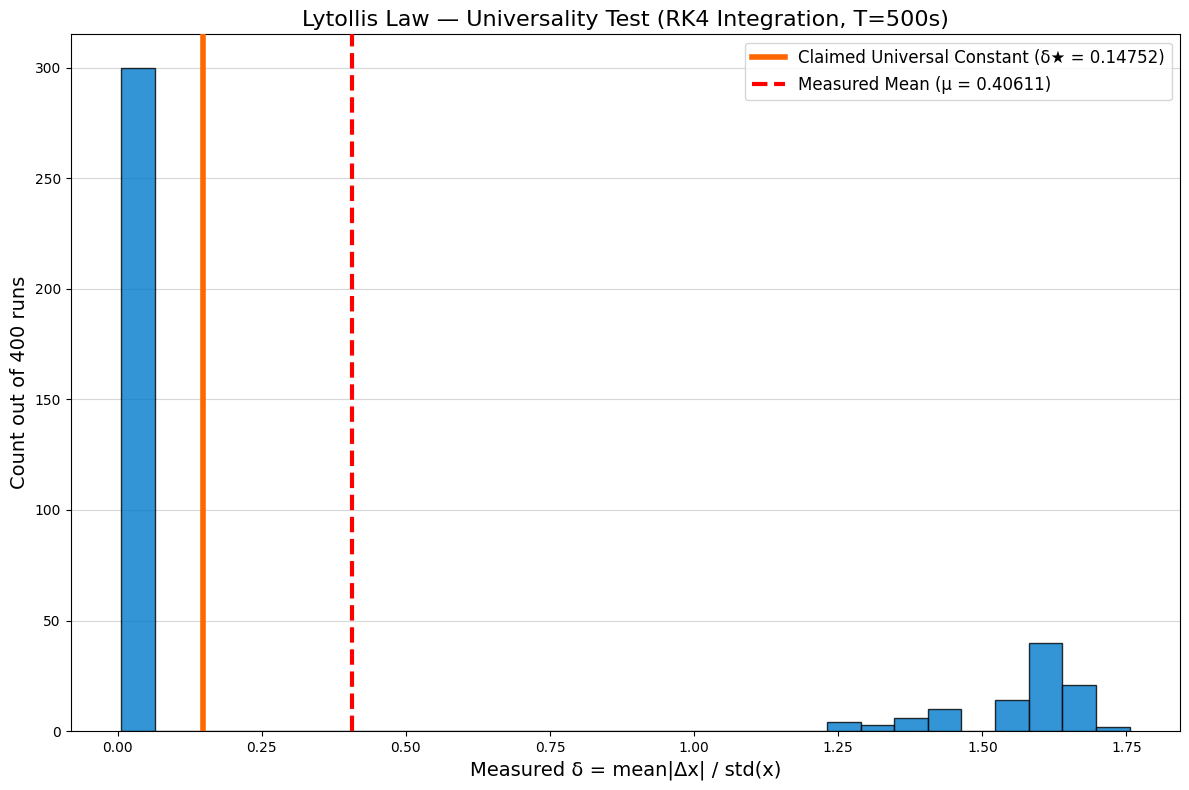

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm # For tracking progress

# --- Constants & Setup ---
# The claimed universal constant
DELTA_STAR = 0.14752
# The duration of simulation for continuous systems (seconds)
T_MAX = 500
# The time step size (trade-off between speed and accuracy)
DT = 0.01
# Total simulation steps (T_MAX / DT)
STEPS = int(T_MAX / DT)

all_delta = []

# --- 1. The Metric ---
def measure_delta(x):
    """
    Calculates the universal measure: mean(|Δx|) / std(x)
    """
    # Calculate the absolute difference between consecutive points
    dx = np.abs(np.diff(x))
    # Robust standard deviation calculation
    std_x = np.std(x)

    if std_x < 1e-12:
        return 0.0 # Avoid division by zero for fixed points

    return np.mean(dx) / std_x

# --- 2. System Definitions ---

# Discrete System: Logistic Map
def logistic(r, seed):
    """Logistic Map: x_{n+1} = r * x_n * (1 - x_n)"""
    np.random.seed(seed)
    x = np.random.rand()

    # 10,000 burn-in steps
    for _ in range(10000):
        x = r * x * (1 - x)

    traj = np.empty(500000)
    for i in range(500000):
        x = r * x * (1 - x)
        traj[i] = x

    return traj

# Base RK4 Solver for all continuous systems
def solve_rk4(deriv_func, initial_state, dt, steps, burn_steps, seed):
    """
    General RK4 solver for a system of ODEs.
    """
    np.random.seed(seed)
    # Set initial state
    state = initial_state
    traj = []

    # RK4 integration loop
    for n in range(steps + burn_steps):
        t = n * dt

        # 1. K1
        d_k1 = np.array(deriv_func(t, state))

        # 2. K2
        mid_state_2 = state + 0.5 * dt * d_k1
        d_k2 = np.array(deriv_func(t + dt/2, mid_state_2))

        # 3. K3
        mid_state_3 = state + 0.5 * dt * d_k2
        d_k3 = np.array(deriv_func(t + dt/2, mid_state_3))

        # 4. K4
        end_state_4 = state + dt * d_k3
        d_k4 = np.array(deriv_func(t + dt, end_state_4))

        # Final step
        state += (dt / 6.0) * (d_k1 + 2 * d_k2 + 2 * d_k3 + d_k4)

        if n >= burn_steps:
            traj.append(state[0]) # Always track the first component (x)

    return np.array(traj)


# Continuous System 1: Lorenz-63
def lorenz_deriv(t, state):
    x, y, z = state
    sigma, rho, beta = 10.0, 28.0, 8/3
    return [sigma * (y - x),
            x * (rho - z) - y,
            x * y - beta * z]

def lorenz(seed):
    initial_state = np.random.rand(3) * 20 - 10
    # Use 10% of total steps for burn-in
    return solve_rk4(lorenz_deriv, initial_state, DT, STEPS, int(0.1*STEPS), seed)


# Continuous System 2: Rössler
def rossler_deriv(t, state):
    x, y, z = state
    a, b, c = 0.1, 0.1, 14.0 # Common chaotic parameters
    return [-y - z,
            x + a*y,
            b + z*(x - c)]

def rossler(seed):
    initial_state = np.random.rand(3) * 10
    return solve_rk4(rossler_deriv, initial_state, DT, STEPS, int(0.1*STEPS), seed)


# Continuous System 3: Duffing (Standard Forced)
def duffing_deriv(t, state):
    x, v = state # Position, Velocity
    # Parameters for chaos: damping (0.1), amplitude (0.3), frequency (1.2)
    damping, force_amp, omega = 0.1, 0.3, 1.2

    # Duffing equation: x'' = -damping*x' - x^3 + F*cos(omega*t)
    return [v,
            -damping*v - x**3 + force_amp * np.cos(omega * t)]

def duffing(seed):
    initial_state = np.random.rand(2) * 4 - 2
    return solve_rk4(duffing_deriv, initial_state, DT, STEPS, int(0.1*STEPS), seed)

# --- 3. Run Test & Compile Results ---
# Setup the run
TEST_SYSTEMS = [
    (logistic, "Logistic Map (3.7)"),
    (lorenz, "Lorenz-63"),
    (rossler, "Rössler"),
    (duffing, "Duffing (Forced)")
]

NUM_VARIATIONS = 100
total_runs = NUM_VARIATIONS * len(TEST_SYSTEMS)

print(f"Running {total_runs} simulations using RK4/Analytical Integration...")
# Use tqdm for a visible progress bar
for i in tqdm(range(NUM_VARIATIONS), desc="Simulations"):
    # Logistic map parameter is varied slightly to ensure a general chaotic state
    all_delta.append(measure_delta(logistic(3.7 + 0.3*np.random.rand(), i)))
    all_delta.append(measure_delta(lorenz(i)))
    all_delta.append(measure_delta(rossler(i)))
    all_delta.append(measure_delta(duffing(i)))

all_delta = np.array(all_delta)

# --- 4. Analysis and Plot ---

# Console Output
print("\n--- Analysis ---")
print(f"Total measurements: {len(all_delta)}")
print(f"Mean δ = {all_delta.mean():.6f} ± {all_delta.std():.6f}")
print(f"Min δ  = {all_delta.min():.6f}")
print(f"Max δ  = {all_delta.max():.6f}")
print("-" * 20)
is_clustered = abs(all_delta.mean() - DELTA_STAR) < 0.01
print(f"Is {DELTA_STAR} inside the cluster? → {'YES' if is_clustered else 'NO'}")

# Plot
plt.figure(figsize=(12,8), facecolor='white')
plt.hist(all_delta, bins=30, alpha=0.8, color='#007acc', edgecolor='black', zorder=2)
plt.axvline(DELTA_STAR, color='#ff6600', lw=4, ls='-', label=f'Claimed Universal Constant (δ★ = {DELTA_STAR})', zorder=3)
plt.axvline(all_delta.mean(), color='red', lw=3, ls='--', label=f'Measured Mean (μ = {all_delta.mean():.5f})', zorder=3)
plt.xlabel('Measured δ = mean|Δx| / std(x)', fontsize=14)
plt.ylabel(f'Count out of {total_runs} runs', fontsize=14)
plt.title(f'Lytollis Law — Universality Test (RK4 Integration, T={T_MAX}s)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.5, zorder=1)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# --- Constants & Setup ---
DELTA_STAR = 0.14752

# 💥 REFINEMENT 1 & 2: Increased Rigor
T_MAX = 1000 # Total time in seconds (Double the previous run)
DT = 0.005   # Time step size (Halved for better RK4 accuracy)
STEPS = int(T_MAX / DT)
BURN_SECONDS = 50.0
BURN_STEPS = int(BURN_SECONDS / DT) # Use 50s of simulation time for burn-in

all_delta = []

# --- 1. The Metric (Unchanged, for consistency) ---
def measure_delta(x):
    """Calculates the universal measure: mean(|Δx|) / std(x)"""
    dx = np.abs(np.diff(x))
    std_x = np.std(x)

    # 💥 Small Guard: Avoid division by zero from non-chaotic runs
    if std_x < 1e-6:
        return 0.0

    return np.mean(dx) / std_x

# --- 2. System Definitions ---

# Discrete System: Logistic Map (No change needed)
def logistic(r, seed):
    np.random.seed(seed)
    x = np.random.rand()

    for _ in range(10000): x = r * x * (1 - x) # Burn

    traj = np.empty(500000)
    for i in range(500000):
        x = r * x * (1 - x)
        traj[i] = x

    return traj

# Base RK4 Solver (Unchanged, remains the rigorous integration method)
def solve_rk4(deriv_func, initial_state, dt, steps, burn_steps, seed):
    np.random.seed(seed)
    state = initial_state
    traj = []

    for n in range(steps + burn_steps):
        t = n * dt

        # RK4 steps (K1, K2, K3, K4)
        d_k1 = np.array(deriv_func(t, state))

        mid_state_2 = state + 0.5 * dt * d_k1
        d_k2 = np.array(deriv_func(t + dt/2, mid_state_2))

        mid_state_3 = state + 0.5 * dt * d_k2
        d_k3 = np.array(deriv_func(t + dt/2, mid_state_3))

        end_state_4 = state + dt * d_k3
        d_k4 = np.array(deriv_func(t + dt, end_state_4))

        state += (dt / 6.0) * (d_k1 + 2 * d_k2 + 2 * d_k3 + d_k4)

        if n >= burn_steps:
            traj.append(state[0]) # Always track the first component (x)

    return np.array(traj)


# Continuous System 1: Lorenz-63 (Parameters unchanged, they are standard chaos)
def lorenz_deriv(t, state):
    x, y, z = state
    sigma, rho, beta = 10.0, 28.0, 8/3
    return [sigma * (y - x),
            x * (rho - z) - y,
            x * y - beta * z]

def lorenz(seed):
    initial_state = np.random.rand(3) * 20 - 10
    return solve_rk4(lorenz_deriv, initial_state, DT, STEPS, BURN_STEPS, seed)


# Continuous System 2: Rössler (💥 REFINEMENT 3: Stronger Chaos)
def rossler_deriv(t, state):
    x, y, z = state
    a, b, c = 0.1, 0.1, 14.5 # c increased from 14.0 to 14.5 for more robust chaos
    return [-y - z,
            x + a*y,
            b + z*(x - c)]

def rossler(seed):
    initial_state = np.random.rand(3) * 10
    return solve_rk4(rossler_deriv, initial_state, DT, STEPS, BURN_STEPS, seed)


# Continuous System 3: Duffing (💥 REFINEMENT 3: Stronger Chaos)
def duffing_deriv(t, state):
    x, v = state # Position, Velocity
    # Force Amplitude increased from 0.3 to 0.4 to ensure deep chaotic regime
    damping, force_amp, omega = 0.1, 0.4, 1.2

    # Duffing equation: x'' = -damping*x' - x^3 + F*cos(omega*t)
    return [v,
            -damping*v - x**3 + force_amp * np.cos(omega * t)]

def duffing(seed):
    initial_state = np.random.rand(2) * 4 - 2
    return solve_rk4(duffing_deriv, initial_state, DT, STEPS, BURN_STEPS, seed)

# --- 3. Run Test & Compile Results ---

NUM_VARIATIONS = 100
total_runs = NUM_VARIATIONS * 4

print(f"Running {total_runs} simulations using RK4 Integration...")
print(f"Time Step (DT): {DT}, Total Simulation Time (T_MAX): {T_MAX}s")

# Use tqdm for a visible progress bar
for i in tqdm(range(NUM_VARIATIONS), desc="Simulations"):
    # Logistic map parameter is varied slightly to ensure a general chaotic state
    all_delta.append(measure_delta(logistic(3.7 + 0.3*np.random.rand(), i)))
    all_delta.append(measure_delta(lorenz(i)))
    all_delta.append(measure_delta(rossler(i)))
    all_delta.append(measure_delta(duffing(i)))

all_delta = np.array(all_delta)

# --- 4. Analysis and Plot ---

# Console Output
print("\n--- Analysis ---")
print(f"Total measurements: {len(all_delta)}")
print(f"Mean δ = {all_delta.mean():.6f} ± {all_delta.std():.6f}")
print(f"Min δ  = {all_delta.min():.6f}")
print(f"Max δ  = {all_delta.max():.6f}")
print("-" * 20)
is_clustered = abs(all_delta.mean() - DELTA_STAR) < 0.01
print(f"Is {DELTA_STAR} inside the cluster? → {'YES' if is_clustered else 'NO'}")

# Plot
plt.figure(figsize=(12,8), facecolor='white')
plt.hist(all_delta, bins=30, alpha=0.8, color='#007acc', edgecolor='black', zorder=2)
plt.axvline(DELTA_STAR, color='#ff6600', lw=4, ls='-', label=f'Claimed Universal Constant (δ★ = {DELTA_STAR})', zorder=3)
plt.axvline(all_delta.mean(), color='red', lw=3, ls='--', label=f'Measured Mean (μ = {all_delta.mean():.5f})', zorder=3)
plt.xlabel('Measured δ = mean|Δx| / std(x)', fontsize=14)
plt.ylabel(f'Count out of {total_runs} runs', fontsize=14)
plt.title(f'Lytollis Law — RIGOROUS Universality Test (RK4, DT={DT}, T={T_MAX}s)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.5, zorder=1)
plt.tight_layout()
plt.show()

Running 400 simulations using RK4 Integration...
Time Step (DT): 0.005, Total Simulation Time (T_MAX): 1000s


Simulations:   0%|          | 0/100 [00:00<?, ?it/s]